In [8]:
from real_GA import real_GA
from csd_GA import csd_GA
from csd2_GA import csd2_GA
from fitness import *
from selection import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz

In [9]:
def target_function(w):
    if w <= 1.3:
        return 1.0
    elif w >= 1.55:
        return 0.0
    else:
        return None   # ignore transition band

In [10]:
real_best, real_best_hist = real_GA(n_pop=100, generations=500, target=target_function, order=29, worN=2048, elitism=True)

In [11]:
csd_best, csd_best_hist = csd_GA(n_pop=100, generations=500, target=target_function, order=29, worN=2048, elitism=True)

In [12]:
csd2_best, csd2_best_hist = csd2_GA(n_pop=100, generations=500, target=target_function, order=29, worN=2048, elitism=True)

In [13]:
# Frequency responses
w, H_real = freqz(real_best.genome)
_, H_csd = freqz(csd_best.coeffs)
_, H_csd2 = freqz(csd2_best.coeffs)
Ht = np.array([target_function(wi) for wi in w], dtype=complex)

# Magnitude / phase
mag_real = np.abs(H_real)
mag_csd = np.abs(H_csd)
mag_csd2 = np.abs(H_csd2)
magt = np.abs(Ht)

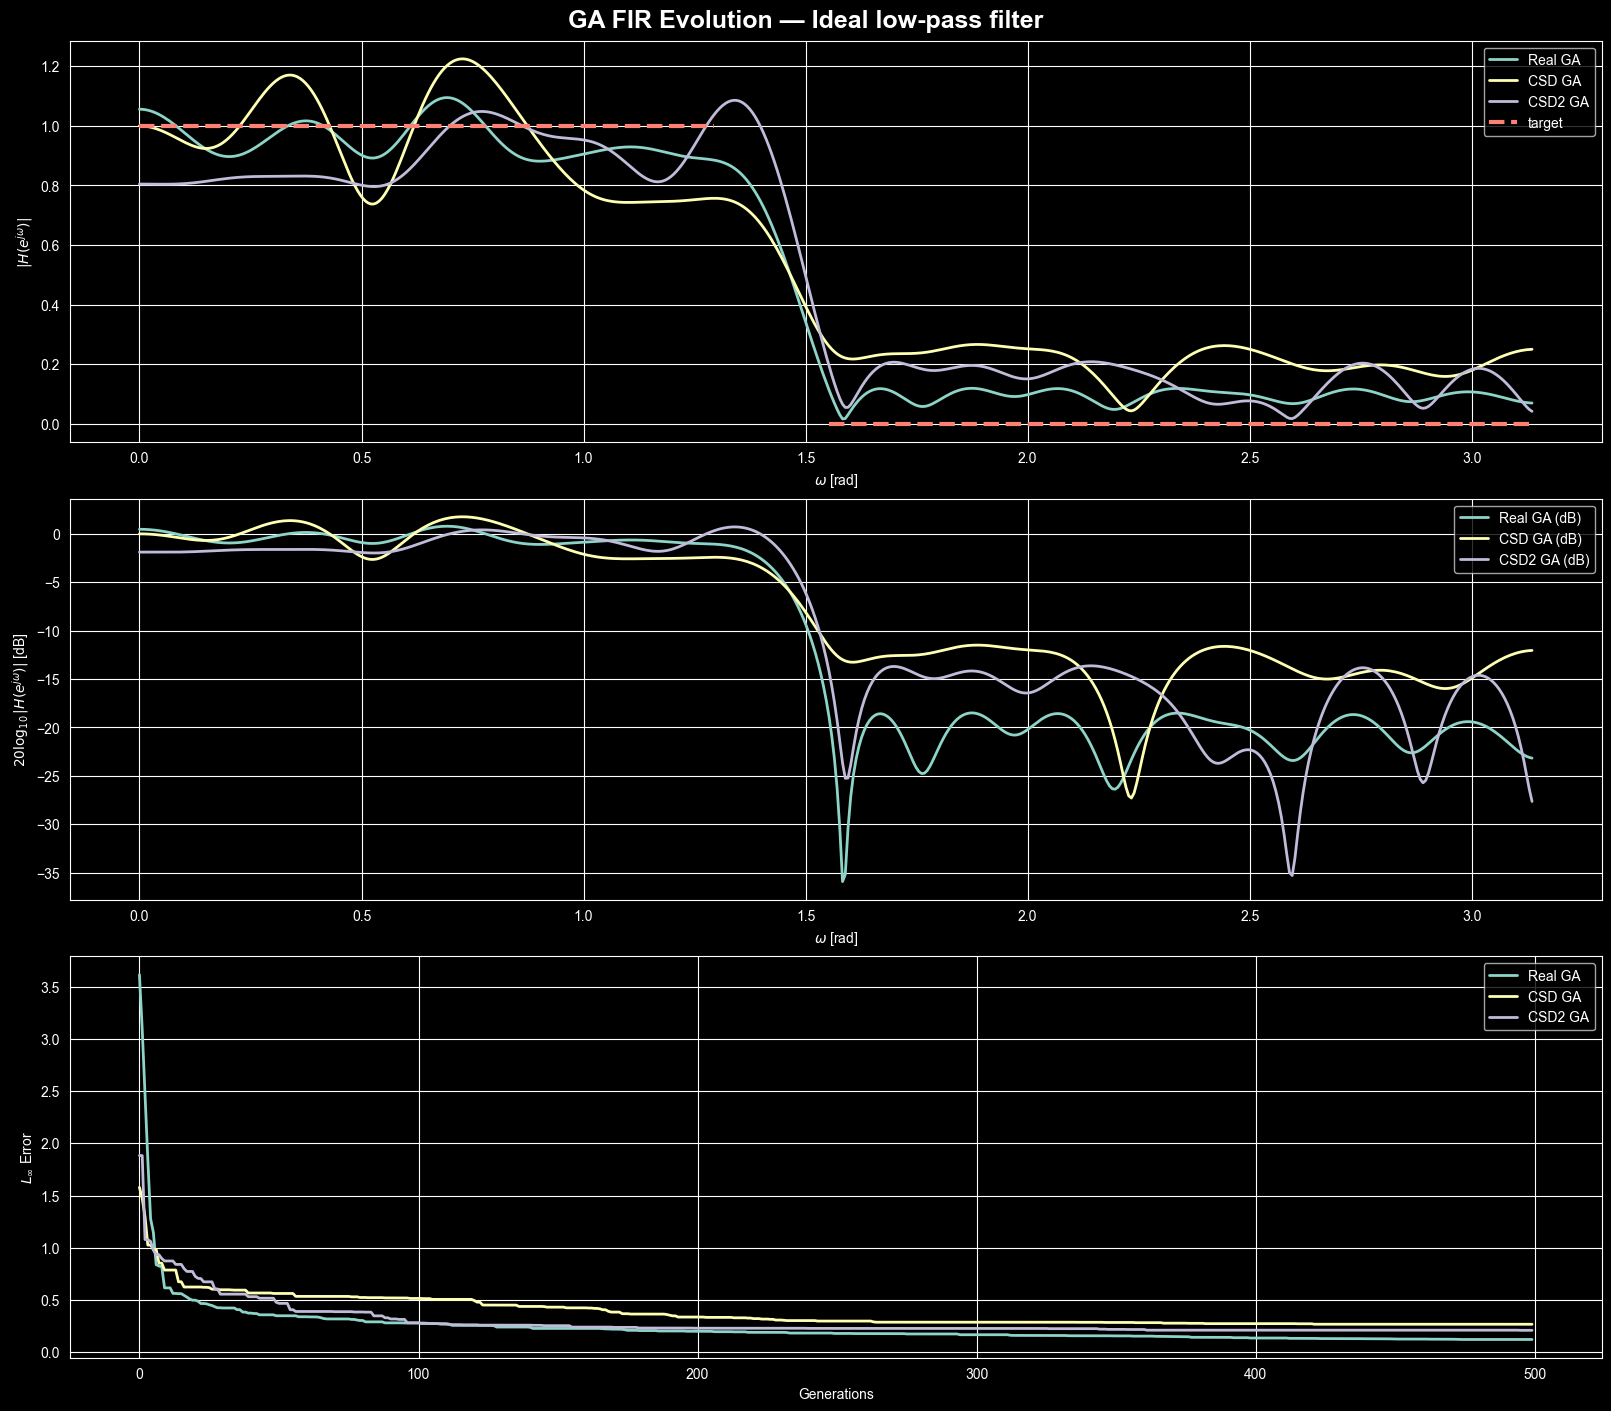

In [14]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(16, 14),
    constrained_layout=True
)

fig.suptitle(
    "GA FIR Evolution — Ideal low-pass filter",
    fontsize=18,
    weight="bold"
)

# -----------------------------
# Row 1 — Linear magnitude
# -----------------------------
ax = axes[0]
ax.plot(w, mag_real, lw=2, label="Real GA")
ax.plot(w, mag_csd, lw=2, label="CSD GA")
ax.plot(w, mag_csd2, lw=2, label="CSD2 GA")
ax.plot(w, magt, lw=3, ls="--", label="target")
ax.set_xlabel(r"$\omega$ [rad]")
ax.set_ylabel(r"$|H(e^{j\omega})|$")
ax.legend()
ax.grid(True)

# -----------------------------
# Row 2 — Magnitude in dB
# -----------------------------
mag_real_db  = 20 * np.log10(mag_real + 1e-12)
mag_csd_db = 20 * np.log10(mag_csd + 1e-12)
mag_csd2_db = 20 * np.log10(mag_csd2 + 1e-12)
magt_db = 20 * np.log10(magt + 1e-12)

ax = axes[1]
ax.plot(w, mag_real_db, lw=2, label="Real GA (dB)")
ax.plot(w, mag_csd_db, lw=2, label="CSD GA (dB)")
ax.plot(w, mag_csd2_db, lw=2, label="CSD2 GA (dB)")
ax.set_xlabel(r"$\omega$ [rad]")
ax.set_ylabel(r"$20\log_{10}|H(e^{j\omega})|$ [dB]")
ax.legend()
ax.grid(True)

# -----------------------------
# Row 3 — L∞ error evolution
# -----------------------------
ax = axes[2]
ax.plot(
    np.arange(len(real_best_hist)),
    [-e.fitness for e in real_best_hist],
    lw=2,
    label="Real GA"
)
ax.plot(
    np.arange(len(csd_best_hist)),
    [-e.fitness for e in csd_best_hist],
    lw=2,
    label="CSD GA"
)
ax.plot(
    np.arange(len(csd2_best_hist)),
    [-e.fitness for e in csd2_best_hist],
    lw=2,
    label="CSD2 GA"
)
ax.set_xlabel("Generations")
ax.set_ylabel(r"$L_\infty$ Error")
ax.legend()
ax.grid(True)

plt.show()